# Análise do Dataset Car Crash

Este notebook realiza análises e visualizações utilizando o dataset **Car Crash**.
Roteiro:
1. **Compreensão Inicial dos Dados**
   - Carregar e visualizar o dataset
   - Resumo estatístico

2. **Análise Univariada**
   - Distribuições das variáveis numéricas
   - Boxplots

3. **Análise Bivariada**
   - Gráficos de dispersão (Scatter plots)
   - Pairplots

4. **Análise Multivariada**
   - Gráficos tridimensionais
   - Heatmap de correlação

5. **Conclusões e Insights**

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compreensão Inicial dos Dados


## Carregar o Dataset e Visualizar os Dados

In [74]:
data = pd.read_csv('monroe county car crach 2003-2015.csv',encoding='latin1')

In [75]:
data.head(10)

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625
5,2015,1,6,Weekday,1800.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,BURKS & WALNUT,39.126670,-86.531370
6,2015,1,6,Weekday,1200.0,2-Car,No injury/unknown,DRIVER DISTRACTED - EXPLAIN IN NARRATIVE,SOUTH CURRY PIKE LOT 71,39.150825,-86.584899
7,2015,1,6,Weekday,1400.0,1-Car,Incapacitating,ENGINE FAILURE OR DEFECTIVE,NORTH LOUDEN RD,39.199272,-86.637024
8,2015,1,7,Weekend,1400.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,LIBERTY & W 3RD,39.164610,-86.579130
9,2015,1,7,Weekend,1600.0,1-Car,No injury/unknown,RAN OFF ROAD RIGHT,PATTERSON & W 3RD,39.163440,-86.551280


In [76]:
data.info

<bound method DataFrame.info of        Year  Month  Day Weekend?    Hour Collision Type         Injury Type  \
0      2015      1    5  Weekday     0.0          2-Car   No injury/unknown   
1      2015      1    6  Weekday  1500.0          2-Car   No injury/unknown   
2      2015      1    6  Weekend  2300.0          2-Car  Non-incapacitating   
3      2015      1    7  Weekend   900.0          2-Car  Non-incapacitating   
4      2015      1    7  Weekend  1100.0          2-Car   No injury/unknown   
...     ...    ...  ...      ...     ...            ...                 ...   
53938  2003     10    6  Weekday  1700.0          2-Car   No injury/unknown   
53939  2003     11    3  Weekday   800.0          1-Car   No injury/unknown   
53940  2003     12    5  Weekday  1200.0          2-Car   No injury/unknown   
53941  2003     12    1  Weekend   700.0          2-Car   No injury/unknown   
53942  2003     12    7  Weekend  1700.0          2-Car  Non-incapacitating   

                   

In [77]:
data['Injury Type'].value_counts()

Injury Type
No injury/unknown     41603
Non-incapacitating    11136
Incapacitating         1089
Fatal                   115
Name: count, dtype: int64

**Consultando dados nulos ou Missing Values no Dataframe**

In [78]:
data.isnull().sum()

Year                    0
Month                   0
Day                     0
Weekend?               68
Hour                  225
Collision Type          6
Injury Type             0
Primary Factor       1121
Reported_Location      35
Latitude               30
Longitude              30
dtype: int64

## Tipo do Objeto carregado

In [79]:
type(data)

pandas.core.frame.DataFrame

## Estatísticas Descritivas

In [80]:
# Exibir estatísticas descritivas
print("\nEstatísticas descritivas:")
print(data.describe())


Estatísticas descritivas:
               Year         Month           Day          Hour      Latitude  \
count  53943.000000  53943.000000  53943.000000  53718.000000  53913.000000   
mean    2008.968059      6.662162      4.196912   1347.265349     35.582109   
std        3.789760      3.514630      1.909440    531.654039     11.289883   
min     2003.000000      1.000000      1.000000      0.000000      0.000000   
25%     2006.000000      4.000000      3.000000   1000.000000     39.142048   
50%     2009.000000      7.000000      4.000000   1400.000000     39.164430   
75%     2012.000000     10.000000      6.000000   1700.000000     39.173344   
max     2015.000000     12.000000      7.000000   2300.000000     41.228665   

          Longitude  
count  53913.000000  
mean     -78.619224  
std       24.957587  
min      -88.959213  
25%      -86.551520  
50%      -86.530992  
75%      -86.508288  
max       86.596363  


## Lista das Injury Type únicas no dataset

In [81]:
data['Injury Type'].unique()

array(['No injury/unknown', 'Non-incapacitating', 'Incapacitating',
       'Fatal'], dtype=object)

## Filtrar Dados: Tipo de Injuria 'Fatal'

In [82]:
# Filtrar dados: Selecionar apenas as amostras de tipos de injúria 'Fatal'
fatal = data[data['Injury Type'] == 'Fatal']
print("\nAmostras do tipo de injúria 'Fatal':")
print(fatal.head())


Amostras do tipo de injúria 'Fatal':
      Year  Month  Day Weekend?    Hour    Collision Type Injury Type  \
530   2015      4    6  Weekday  1600.0             1-Car       Fatal   
531   2015      4    7  Weekend  1500.0             2-Car       Fatal   
649   2015      1    4  Weekday  1700.0             2-Car       Fatal   
1334  2015      4    1  Weekend   700.0             1-Car       Fatal   
1873  2015      6    3  Weekday  2200.0  Moped/Motorcycle       Fatal   

                             Primary Factor           Reported_Location  \
530                      RAN OFF ROAD RIGHT  DUNCAN & W LEONARD SPRINGS   
531                      RAN OFF ROAD RIGHT          KIRBY & W ST RD 48   
649   OTHER (DRIVER) - EXPLAIN IN NARRATIVE                       SR 45   
1334                     RAN OFF ROAD RIGHT              INGRAM & SR37N   
1873                     RAN OFF ROAD RIGHT       SR37S & STATE ROAD 45   

       Latitude  Longitude  
530   39.122352 -86.596400  
531   39.05918

# 2. Análise Univariada

## Distribuições das variáveis numéricas

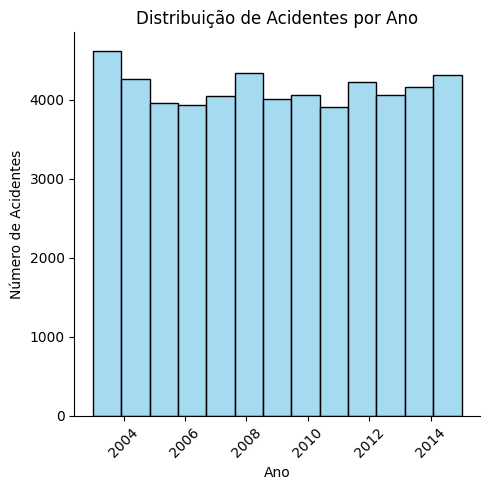

In [83]:
sns.displot(data=data, x='Year', kde=False, bins=len(data['Year'].unique()), color="skyblue")
plt.title('Distribuição de Acidentes por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Gráfico de densidade (sns.kdeplot) para todos os tipos de colisão

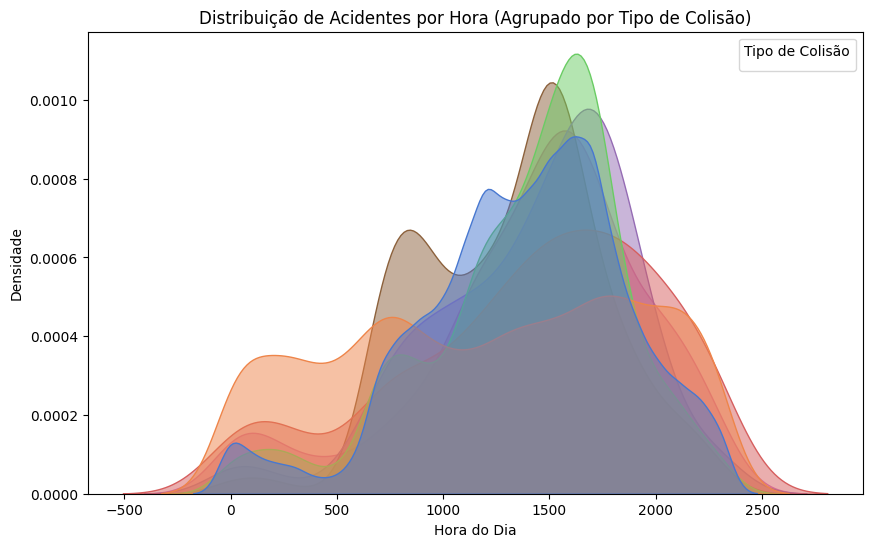

In [84]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='Hour', hue='Collision Type', fill=True, common_norm=False, alpha=0.5, palette='muted')
plt.title("Distribuição de Acidentes por Hora (Agrupado por Tipo de Colisão)")
plt.xlabel("Hora do Dia")
plt.ylabel("Densidade")
plt.legend(title="Tipo de Colisão")
plt.show()

## Conclusão do Gráfico de Densidade (sns.kdeplot)

- **Horários de maior densidade de acidentes**:
  - A maioria dos acidentes ocorre durante horários de maior fluxo, como manhãs e tardes, com picos perceptíveis nesses períodos.
  - Para acidentes mais graves, como os fatais ou incapacitantes, observa-se uma tendência de maior ocorrência em horários noturnos ou em períodos de menor tráfego.

- **Distribuição por tipos de colisão**:
  - Os tipos de colisão mais comuns apresentam picos mais acentuados, sugerindo horários consistentes de ocorrência.
  - Colisões menos frequentes, como com pedestres ou motocicletas, possuem distribuições mais dispersas, refletindo eventos mais aleatórios.

- **Fatores contextuais**:
  - A densidade de acidentes pode estar correlacionada com condições ambientais, como iluminação e volume de tráfego, além de padrões de uso das vias.
  - Acidentes em horários de maior densidade geralmente estão associados ao tráfego de pico, enquanto acidentes em horários atípicos podem indicar condições adversas ou imprudência.

O gráfico de densidade é uma ferramenta poderosa para identificar padrões temporais em acidentes de trânsito, permitindo análises mais detalhadas sobre horários críticos e potenciais intervenções de segurança.


### Histograma

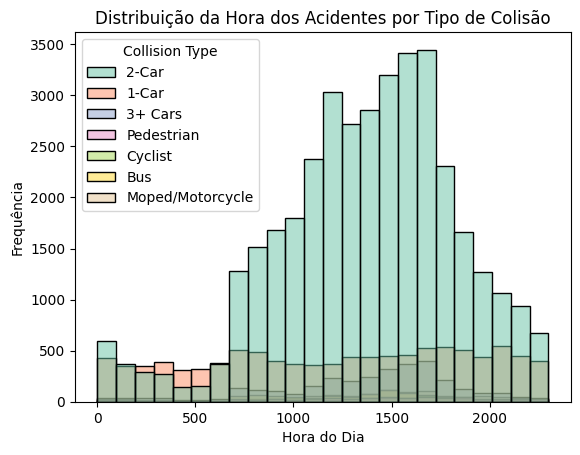

In [85]:
sns.histplot(data=data, x='Hour', hue='Collision Type', fill=True, common_norm=False, bins=24, palette="Set2")
plt.title('Distribuição da Hora dos Acidentes por Tipo de Colisão')
plt.xlabel('Hora do Dia')
plt.ylabel('Frequência')
plt.show()


### Boxplot: Hora do Acidente por Tipo de Lesão

<Axes: xlabel='Hour', ylabel='Injury Type'>

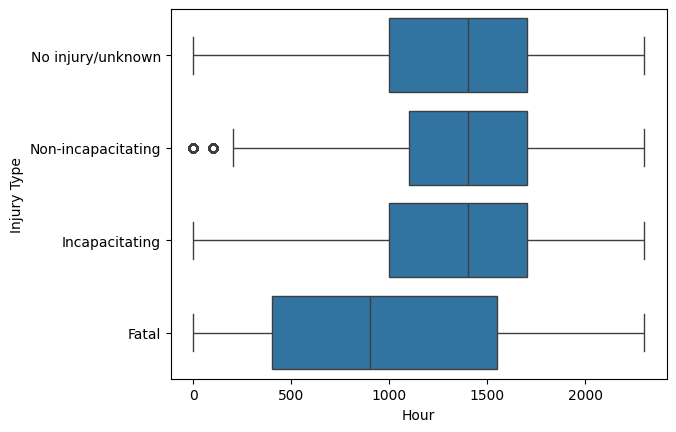

In [86]:
sns.boxplot(data=data, x='Hour', y='Injury Type')

## Conclusão do Gráfico Boxplot: Hora do Acidente por Tipo de Lesão

- **Acidentes sem ferimentos ou desconhecidos (`No injury/unknown`)**:
  - Os horários são mais concentrados em períodos típicos do dia.
  - Menor variabilidade, com a maioria dos acidentes ocorrendo durante o dia.
  - Alguns outliers indicam eventos em horários extremos, mas são casos raros.

- **Acidentes com lesões não incapacitantes (`Non-incapacitating`)**:
  - Apresentam maior variabilidade de horários, indicando ocorrência em diferentes períodos do dia.
  - Alguns acidentes ocorrem em horários não usuais, representados por outliers.

- **Acidentes com lesões incapacitantes (`Incapacitating`)**:
  - Distribuição ampla nos horários de ocorrência, com maior dispersão.
  - A mediana sugere que esses acidentes podem ocorrer mais frequentemente em horários de pico.

- **Acidentes fatais (`Fatal`)**:
  - Distribuição mais concentrada em horários específicos, com menor dispersão.
  - A mediana e os quartis mostram que esses eventos tendem a ocorrer em períodos semelhantes, possivelmente associados a condições mais perigosas.

- **Comparação geral**:
  - Acidentes sem lesões têm horários mais previsíveis, enquanto acidentes com lesões (especialmente incapacitantes e fatais) mostram maior variabilidade.
  - O padrão temporal é útil para identificar fatores de risco em determinados horários.

## Agrupar por ano e calcular a média de cada coluna numérica

In [87]:
media_anos = data.groupby('Year').mean(numeric_only=True)
print("\nMédia de Acidentes por Ano:")
print(media_anos)


Média de Acidentes por Ano:
         Month       Day         Hour   Latitude  Longitude
Year                                                       
2003  6.676757  4.287135  1364.211687  34.135164 -75.422405
2004  6.617241  4.207777  1355.133080  35.137767 -77.637783
2005  6.596420  4.171666  1352.362708  34.742431 -76.764774
2006  6.806452  4.200914  1373.021950  34.399077 -76.007349
2007  6.677189  4.144266  1355.330701  33.987569 -75.097769
2008  6.686708  4.240037  1345.312140  36.044032 -79.640002
2009  6.600897  4.129048  1349.302441  35.778098 -79.056693
2010  6.619704  4.177586  1344.236453  35.777386 -79.057250
2011  6.686765  4.203373  1349.182422  36.736593 -81.165216
2012  6.609519  4.196069  1343.665641  36.357767 -80.346532
2013  6.760227  4.203795  1317.767373  37.470367 -82.806605
2014  6.613391  4.185985  1315.454764  37.070512 -81.865465
2015  6.661952  4.195456  1349.362393  35.068392 -77.486745


# 3. Análise Bivariada

## Gráfico de Dispersão: Latitude vs Longitude dos Acidentes

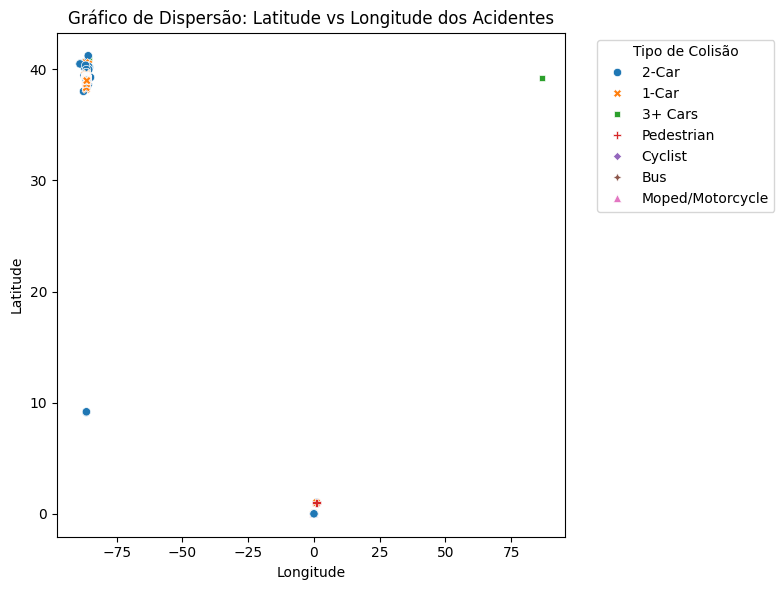

In [88]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Longitude', y='Latitude', hue='Collision Type', style='Collision Type', palette='tab10')
plt.title('Gráfico de Dispersão: Latitude vs Longitude dos Acidentes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Tipo de Colisão', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusão do Gráfico de Dispersão: Latitude vs Longitude dos Acidentes

- **Distribuição espacial dos acidentes**:
  - O gráfico mostra padrões geográficos distintos, com áreas de maior concentração de acidentes em regiões específicas. Locais urbanos ou cruzamentos movimentados destacam-se como pontos de maior densidade.

- **Tipos de colisão**:
  - Cada tipo de colisão apresenta uma distribuição diferente no espaço. Alguns tipos, como colisões envolvendo pedestres, podem estar mais concentrados em áreas urbanas, enquanto acidentes de múltiplos veículos têm uma dispersão mais ampla.

- **Clusters e correlação espacial**:
  - Embora não haja uma relação linear clara entre latitude e longitude, o gráfico evidencia clusters de acidentes que podem estar associados a padrões de tráfego, infraestrutura viária ou outros fatores locais.

- **Identificação de outliers**:
  - Alguns pontos isolados no gráfico podem representar acidentes em áreas menos comuns, como rodovias ou locais de tráfego mais esporádico. Esses casos podem indicar situações excepcionais ou condições específicas que merecem análise detalhada.

- **Importância do gráfico**:
  - Este gráfico é essencial para compreender a distribuição geográfica dos acidentes, identificar áreas de risco e orientar ações preventivas mais eficazes.


## Pairplot: Todas as combinações possíveis em um único gráfico

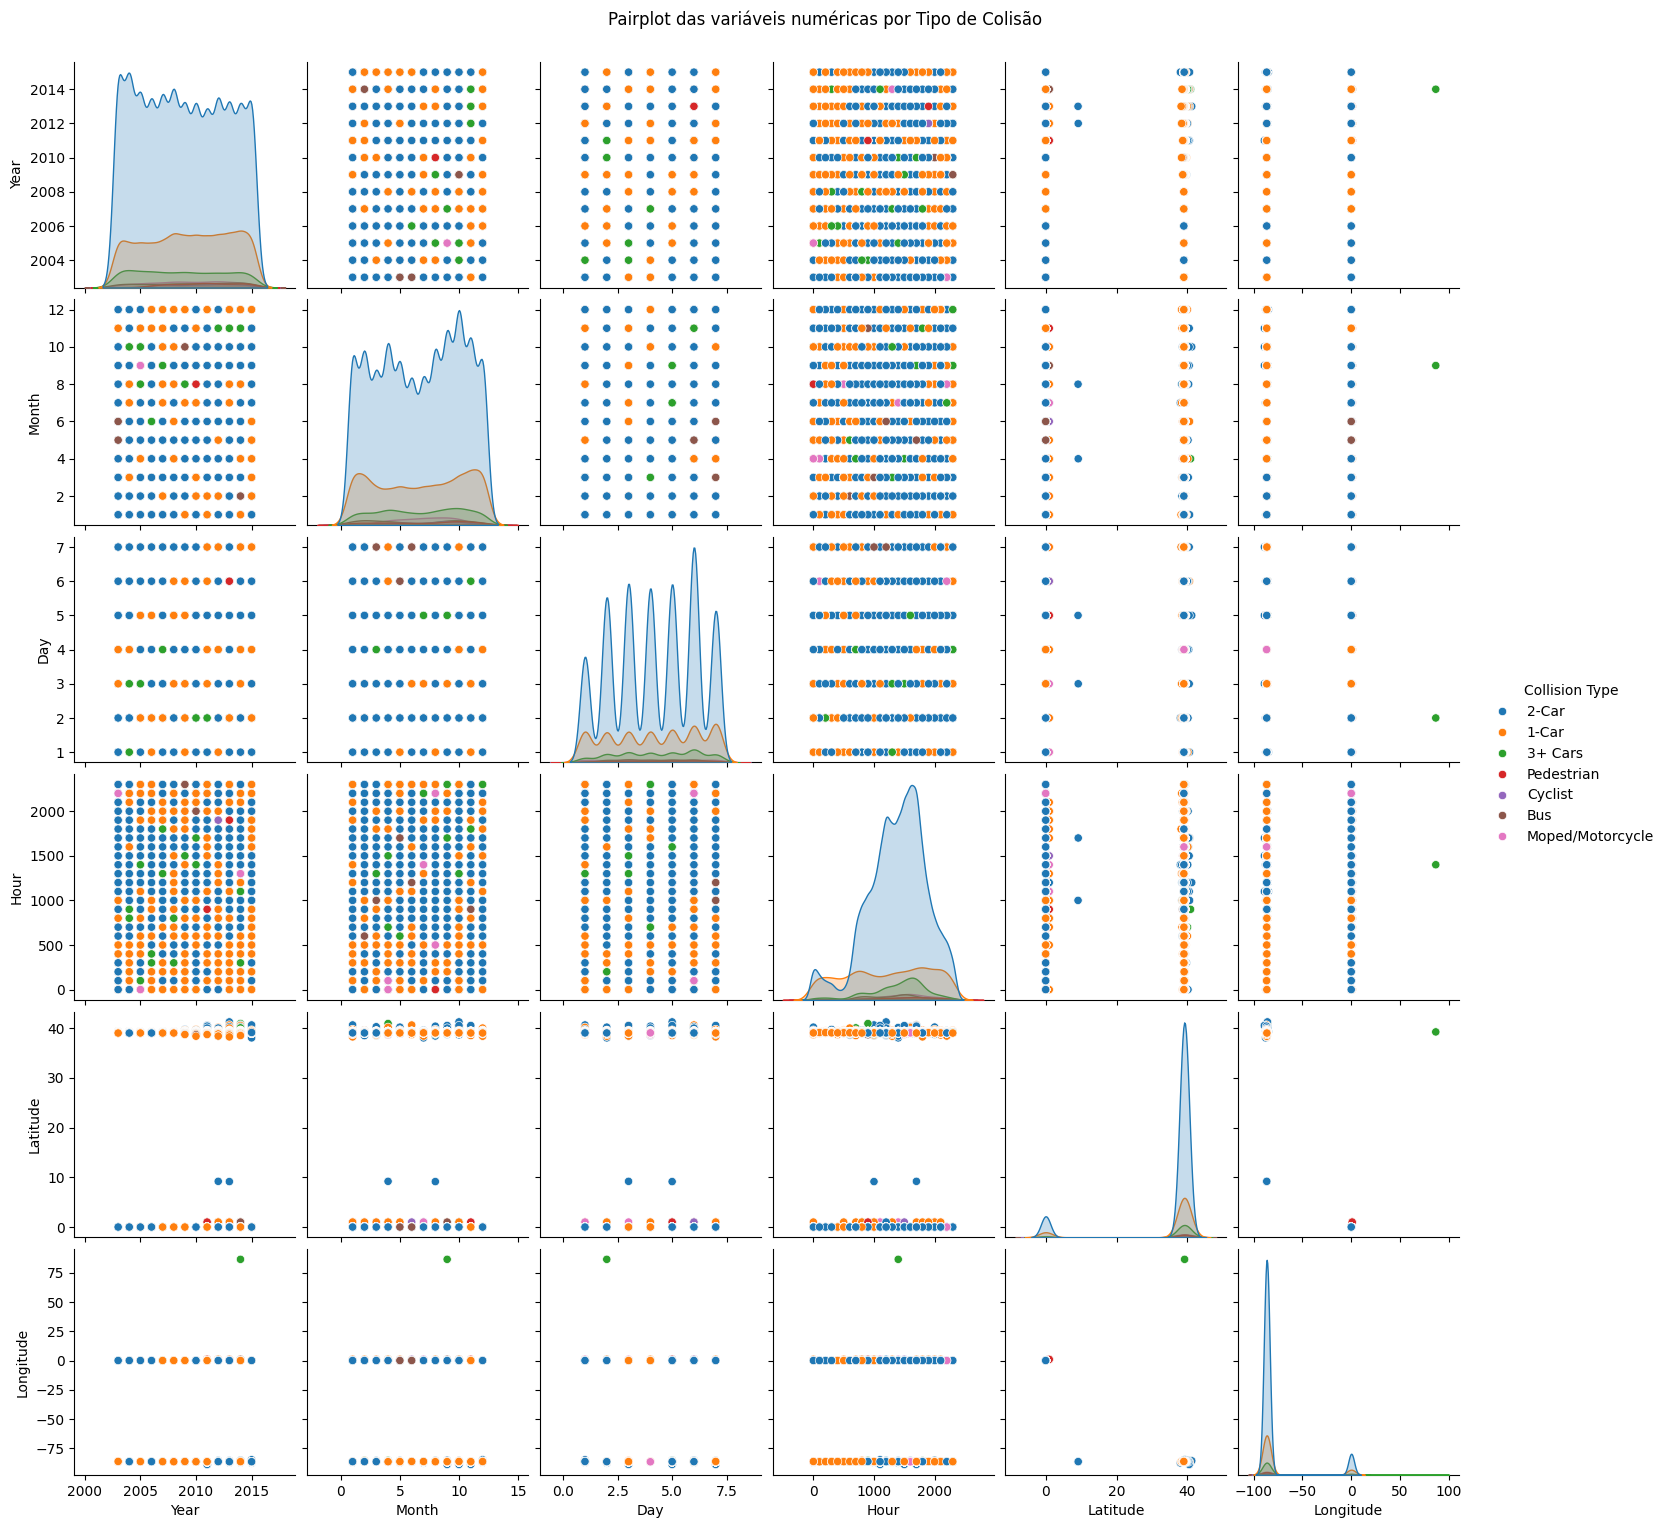

In [89]:
sns.pairplot(data, hue='Collision Type', diag_kind='kde', vars=['Year', 'Month', 'Day', 'Hour', 'Latitude', 'Longitude'])
plt.suptitle('Pairplot das variáveis numéricas por Tipo de Colisão', y=1.02)
plt.show()

## Conclusões do Pairplot: Todas as Combinações Possíveis

- **Separação entre tipos de colisão**:
  - Certos tipos de colisão mostram padrões de distribuição distintos em algumas combinações de variáveis, indicando diferenças nos comportamentos ou condições subjacentes.
  - A sobreposição em várias combinações sugere que variáveis numéricas sozinhas podem não ser suficientes para distinguir todos os tipos de colisão.

- **Relações entre variáveis numéricas**:
  - Correlações leves, como entre `Year` e `Hour`, refletem mudanças temporais nos horários mais comuns de acidentes ao longo dos anos.
  - Relações espaciais, como entre `Latitude` e `Longitude`, mostram agrupamentos associados a áreas geográficas específicas.

- **Distribuição das características**:
  - As distribuições ao longo das diagonais destacam padrões sazonais e horários nos acidentes. Por exemplo, há concentrações distintas em certos meses ou horários do dia.

- **Outliers e variações**:
  - Outliers visíveis podem indicar acidentes em locais ou horários atípicos, oferecendo insights importantes para investigações específicas.

- **Utilidade do pairplot**:
  - Este gráfico fornece uma visão ampla das interações entre variáveis e permite identificar relações importantes, além de padrões de concentração e dispersão.
  - É uma ferramenta essencial para selecionar variáveis-chave para análises mais aprofundadas ou modelagem preditiva.

# 4. Análise Multivariada

## Gráficos tridimensionais:


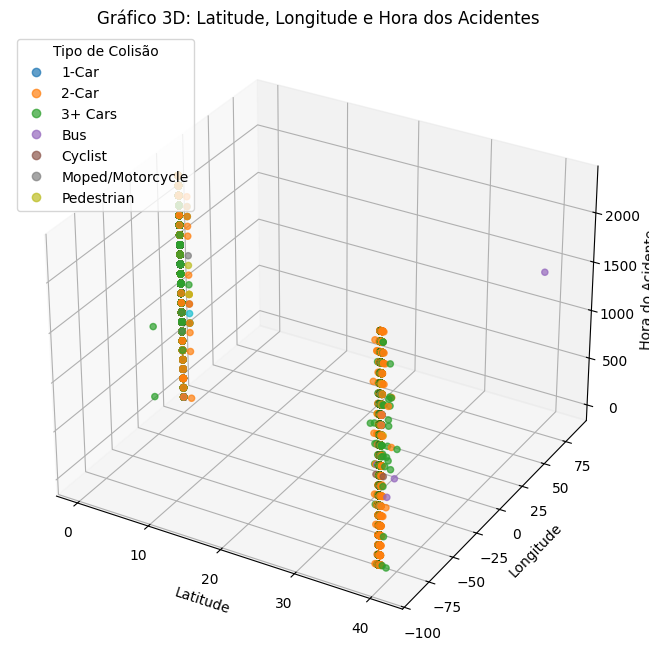

In [90]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Mapeia as categorias para números para colorir
collision_codes = data['Collision Type'].astype('category').cat.codes

scatter = ax.scatter(
    data['Latitude'],
    data['Longitude'],
    data['Hour'],
    c=collision_codes,
    cmap='tab10',
    alpha=0.7
)

ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_zlabel('Hora do Acidente')
ax.set_title('Gráfico 3D: Latitude, Longitude e Hora dos Acidentes')

# Legenda personalizada para os tipos de colisão
handles, _ = scatter.legend_elements()
labels = data['Collision Type'].astype('category').cat.categories
ax.legend(handles, labels, title='Tipo de Colisão', loc='upper left')

plt.show()


## Conclusões do Gráfico 3D: Latitude vs Longitude vs Hora do Acidente

- **Padrões espaciais e temporais:**
  - O gráfico 3D mostra como os acidentes estão distribuídos em termos de latitude, longitude e horário. É possível observar concentrações geográficas específicas, com acidentes agrupados em certas faixas de coordenadas.
  - Em termos de horário, acidentes parecem ocorrer em um intervalo relativamente concentrado, embora haja variações para diferentes tipos de colisão.

- **Diferenciação por tipo de colisão:**
  - Cada tipo de colisão está representado por uma cor distinta no gráfico, permitindo identificar variações entre os tipos. Por exemplo, certos tipos de colisão, como acidentes envolvendo pedestres ou motociclistas, podem estar mais concentrados em áreas específicas.
  - A inclusão de variáveis como hora do acidente permite observar possíveis padrões temporais associados a cada tipo de colisão.

- **Clusters e outliers:**
  - É evidente a formação de clusters, que podem representar áreas de maior incidência de acidentes ou locais críticos.
  - Alguns outliers (pontos isolados) podem indicar acidentes em locais ou horários atípicos, sugerindo a necessidade de uma análise mais detalhada.

- **Interpretação geral:**
  - O gráfico 3D é uma ferramenta poderosa para explorar padrões multidimensionais no dataset. Ele ajuda a relacionar localização geográfica e horário de ocorrência com o tipo de colisão.
  - No entanto, devido à perspectiva e sobreposição de pontos, pode ser difícil visualizar alguns detalhes; gráficos interativos ou filtros adicionais podem ajudar a melhorar a análise.


## Heatmap de correlação:


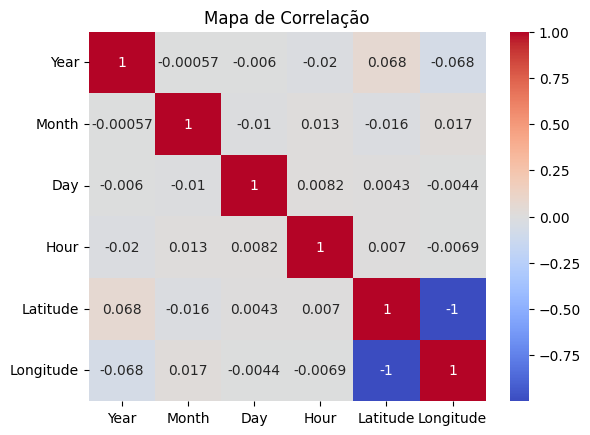

In [92]:
# Selecionar apenas colunas numéricas para a matriz de correlação
corr_matrix = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

### **Interpretação do Heatmap de Correlação:**

- **Relações fortes:**
  - As variáveis **Latitude** e **Longitude** possuem uma correlação negativa perfeita (-1), o que é esperado devido à forma como as coordenadas geográficas são organizadas no espaço (valores negativos em Longitude para o hemisfério ocidental).
  
- **Relações moderadas:**
  - A correlação entre **Latitude** e **Year** é ligeiramente positiva, indicando que, em anos mais recentes, alguns acidentes podem ter ocorrido mais ao norte, mas a relação é muito fraca para uma conclusão sólida.
  
- **Relações fracas ou nulas:**
  - Variáveis temporais como **Month**, **Day**, e **Hour** não mostram correlações significativas com as demais variáveis numéricas, indicando que os padrões temporais são relativamente independentes da localização ou do ano.
  
- **Interpretação geral:**
  - O heatmap revela que não há fortes relações lineares entre a maioria das variáveis do dataset, com exceção da relação perfeita (esperada) entre **Latitude** e **Longitude**.
